### Localized wind bursts
The general picture for these is that they are going to be localized in space and time. We will parameterize a zonal wind burst as:
$$
\tau_x = \tau_0 \prod_{q\in\{x,y,t\}} \sin(\pi(q - q_0)/(q_1-q_0)) 1_{[q_0,q_1]}
$$
where $1_{[q_0,q_1]}$ is the boxcar function for the interval $[q_0,q_1]$.

This translates to the Ekman-transport forcing:
$$
(T_N, M_{Ek, x}, M_{Ek, y}) = (0, 0, -\tau_x / f).
$$
This first set of cells just sets up what is needed to construct these.

In [1]:
from pathlib import Path
from moc_adjustment_theory import EARTH_ROTATION_S, EARTH_RADIUS_M, GlobalRossbyModel, rossby_speed

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data").is_dir() and (path / "notebooks").is_dir()
)
TEMPLATE_FORCING_PATH = (
    PROJECT_ROOT / "data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc"
)

In [2]:
def zonal_wind_burst(
    tau_0: float,
    t_0: np.datetime64,
    t_1: np.datetime64,
    lat_0: float,
    lat_1: float,
    lon_0: float,
    lon_1: float,
    template_forcing_ds: xr.Dataset | None = None,
) -> xr.Dataset:
    """
    Create a zonal wind burst forcing dataset.

    Parameters
    ----------
    tau_0 : float
        Peak eastward kinematic wind-stress anomaly in m2 s-2. Negative
        values produce an easterly burst.
    t_0 : numpy.datetime64
        The start time of the wind burst.
    t_1 : numpy.datetime64
        The end time of the wind burst.
    lat_0 : float
        The southern latitude of the wind burst region.
    lat_1 : float
        The northern latitude of the wind burst region.
    lon_0 : float
        The western longitude of the wind burst region.
    lon_1 : float
        The eastern longitude of the wind burst region.
    template_forcing_ds : xr.Dataset, optional
        Dataset supplying the time, latitude, and longitude coordinates and
        forcing-variable metadata.
        If omitted, ``TEMPLATE_FORCING_PATH`` is opened long enough to load
        its one-dimensional coordinates.

    Returns
    -------
    xr.Dataset
        A lazily evaluated dataset containing ``M_Ek_x``, ``M_Ek_y``, and
        ``T_N`` on the template grid.

    Notes
    -----
    A single signed burst generally has a non-zero time mean. Pair it with
    a compensating forcing or explicitly relax the model's zero-mean check
    when that is the intended experiment.
    """
    if not np.isscalar(tau_0) or not np.isfinite(tau_0):
        raise ValueError("tau_0 must be a finite scalar")

    t_0 = np.datetime64(t_0, "ns")
    t_1 = np.datetime64(t_1, "ns")
    spatial_bounds = np.asarray([lat_0, lat_1, lon_0, lon_1], dtype=float)
    if np.isnat(t_0) or np.isnat(t_1):
        raise ValueError("t_0 and t_1 must be valid datetimes")
    if not np.all(np.isfinite(spatial_bounds)):
        raise ValueError("latitude and longitude bounds must be finite")
    if not (t_0 < t_1 and lat_0 < lat_1 and lon_0 < lon_1):
        raise ValueError("each lower burst bound must be less than its upper bound")
    if lon_1 - lon_0 > 360.0:
        raise ValueError("longitude interval must not exceed 360 degrees")

    if template_forcing_ds is None:
        with xr.open_dataset(TEMPLATE_FORCING_PATH) as source:
            template_forcing_ds = xr.Dataset(
                coords={
                    name: source.coords[name].load().copy(deep=True)
                    for name in ("time", "latitude", "longitude")
                },
                attrs=source.attrs.copy(),
            )
            template_variable_attrs = {
                name: source[name].attrs.copy()
                for name in ("M_Ek_x", "M_Ek_y", "T_N")
                if name in source
            }
    else:
        template_variable_attrs = {
            name: template_forcing_ds[name].attrs.copy()
            for name in ("M_Ek_x", "M_Ek_y", "T_N")
            if name in template_forcing_ds
        }

    missing = {"time", "latitude", "longitude"}.difference(
        template_forcing_ds.coords
    )
    if missing:
        raise ValueError(f"template dataset is missing coordinates: {sorted(missing)}")

    bounds = {
        "time": (t_0, t_1),
        "latitude": (float(lat_0), float(lat_1)),
        "longitude": (float(lon_0), float(lon_1)),
    }
    for name, (lower, upper) in bounds.items():
        coordinate = template_forcing_ds.coords[name]
        if coordinate.dims != (name,) or coordinate.size < 2:
            raise ValueError(f"{name} must be a one-dimensional coordinate")
        values = coordinate.values
        if np.any(np.diff(values) <= 0):
            raise ValueError(f"{name} coordinate must be strictly increasing")
        if name != "longitude" and (lower < values[0] or upper > values[-1]):
            raise ValueError(
                f"{name} bounds [{lower}, {upper}] lie outside the template range "
                f"[{values[0]}, {values[-1]}]"
            )

    def sine_bump(coordinate, lower, upper, chunk_size):
        phase = (coordinate - lower) / (upper - lower)
        envelope = xr.where(
            (coordinate > lower) & (coordinate < upper),
            np.sin(np.pi * phase)**2,
            0.0,
        )
        return envelope.astype(np.float32).chunk(
            {coordinate.dims[0]: min(chunk_size, coordinate.size)}
        )

    time_profile = sine_bump(template_forcing_ds.time, t_0, t_1, 12)
    latitude_profile = sine_bump(
        template_forcing_ds.latitude, lat_0, lat_1, 64
    )
    unwrapped_longitude = (
        (template_forcing_ds.longitude - lon_0) % 360.0 + lon_0
    )
    longitude_profile = sine_bump(unwrapped_longitude, lon_0, lon_1, 128)
    time_envelope, latitude_envelope, longitude_envelope = xr.broadcast(
        time_profile, latitude_profile, longitude_profile
    )
    burst_chunks = {"time": 12, "latitude": 64, "longitude": 128}
    tau_x = np.float32(tau_0)
    for envelope in (time_envelope, latitude_envelope, longitude_envelope):
        tau_x = tau_x * envelope.chunk(burst_chunks)

    coriolis = 2.0 * EARTH_ROTATION_S * np.sin(
        np.deg2rad(template_forcing_ds.latitude)
    )
    if lat_0 < 0.0 < lat_1:
        raise ValueError("a 1/f wind burst cannot cross the equator")
    active_latitude = (
        (template_forcing_ds.latitude > lat_0)
        & (template_forcing_ds.latitude < lat_1)
    )
    safe_coriolis = xr.where(active_latitude, coriolis, 1.0).chunk(
        {"latitude": min(64, coriolis.sizes["latitude"])}
    )

    m_ek_y = (-tau_x / safe_coriolis).astype(np.float32).rename("M_Ek_y")
    m_ek_x = xr.zeros_like(m_ek_y).rename("M_Ek_x")
    t_n = xr.zeros_like(time_profile, dtype=np.float64).rename("T_N")

    m_ek_x.attrs = template_variable_attrs.get("M_Ek_x", {
        "units": "m2 s-1",
        "long_name": "eastward Ekman transport anomaly",
        "positive": "eastward",
    })
    m_ek_y.attrs = template_variable_attrs.get("M_Ek_y", {
        "units": "m2 s-1",
        "long_name": "northward Ekman transport anomaly",
        "positive": "northward",
    })
    t_n.attrs = template_variable_attrs.get("T_N", {
        "units": "m3 s-1",
        "long_name": "total northern Atlantic transport anomaly",
        "positive": "northward",
        "latitude_degrees_north": 55.0,
    })

    forcing = xr.Dataset({"M_Ek_x": m_ek_x, "M_Ek_y": m_ek_y, "T_N": t_n})
    forcing = forcing.transpose(
        "time", "latitude", "longitude", missing_dims="ignore"
    )
    forcing.attrs = {
        "title": "Localized zonal wind-burst forcing",
        "kinematic_wind_stress_amplitude_m2_s2": float(tau_0),
        "EARTH_ROTATION_S_1": EARTH_ROTATION_S,
        "burst_start": np.datetime_as_string(t_0, unit="ns"),
        "burst_end": np.datetime_as_string(t_1, unit="ns"),
        "burst_latitude_bounds_degrees_north": [float(lat_0), float(lat_1)],
        "burst_longitude_bounds_degrees_east": [float(lon_0), float(lon_1)],
        "generated_by": "notebooks/wind_investigation/localized_bursts.ipynb",
    }
    return forcing

### Midlatitude North Atlantic
For the first example, we are going to look at the effects of a zonal burst of winds with strength $\tau_0 = 10^{-4}$ between $20$ and $40$ degrees north for a year-long period. 

In [144]:
mlna_burst = zonal_wind_burst(
    tau_0=-1e-3,
    t_0=np.datetime64("2005-01-01"),
    t_1=np.datetime64("2006-01-01"),
    lat_0=20.0,
    lat_1=40.0,
    lon_0=-30.0,
    lon_1=-20.0,
)

In [145]:
# Solve the model
isobath_ds = xr.open_dataset(PROJECT_ROOT / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc").load()
model = GlobalRossbyModel(isobath_ds, g_prime=0.02)
solution = model.solve(mlna_burst)
h_b = solution.h_b
h = solution.h
T = solution.T
# Compute the travel times
g = solution.attrs["g_prime_m_s-2"]
H = solution.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(isobath_ds.latitude)) * np.radians(isobath_ds.x_eA - isobath_ds.x_wA)
c = rossby_speed(L.latitude, g, H)
tt = L / c

In [146]:
h_b_to_plot = h_b.sel(region="north_atlantic", time=slice("2005-01-01", "2014-01-01"), latitude=slice(0, 50))
h_b_to_plot = h_b_to_plot.compute()
T_to_plot = T.sel(region="north_atlantic", time=slice("2005-01-01", "2014-01-01"), latitude=slice(0, 50))
T_to_plot = T_to_plot.compute()
h_e = solution.h_e.compute()

Text(0.5, 1.0, 'Total northern Atlantic transport anomalies')

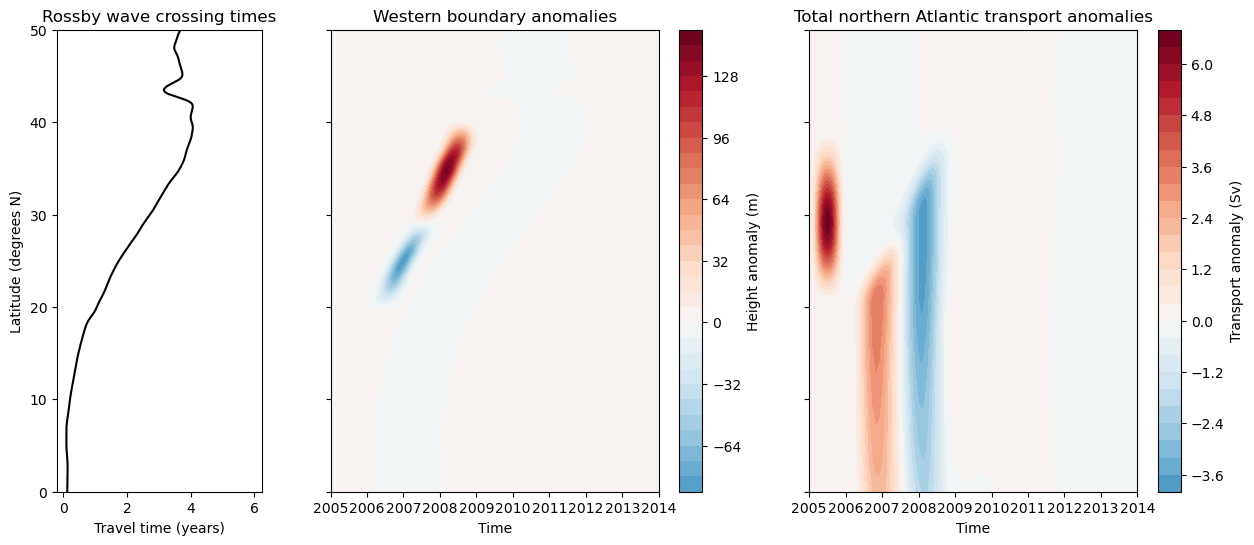

In [147]:
# Plot of travel times and h_b
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=True, width_ratios=[1, 2, 2])
# Plot travel times
tt_yr = tt / (24 * 60 * 60 * 365.25) # Convert seconds to years
tt_ax = axs[0]
tt_ax.plot(tt_yr, tt_yr.latitude, color="black")
tt_ax.set_xlabel("Travel time (years)")
tt_ax.set_ylabel("Latitude (degrees N)")
tt_ax.set_title("Rossby wave crossing times")
# Plot height anomalies over restricted region
h_b_ax = axs[1]
vmax = np.max(np.abs(h_b_to_plot))
ctf = h_b_ax.contourf(h_b_to_plot.time, h_b_to_plot.latitude, h_b_to_plot.T, cmap="RdBu_r", levels=31, norm=mpl.colors.CenteredNorm())
h_b_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=h_b_ax, label="Height anomaly (m)")
h_b_ax.set_title("Western boundary anomalies")
h_b_ax.set_ylim([h_b_to_plot.latitude.min(), h_b_to_plot.latitude.max()])
# Plot transport anomalies over restricted region
T_ax = axs[2]
vmax = np.max(np.abs(T_to_plot))
ctf = T_ax.contourf(T_to_plot.time, T_to_plot.latitude, T_to_plot.T / 1e6, cmap="RdBu_r", levels=31, norm=mpl.colors.CenteredNorm())
T_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=T_ax, label="Transport anomaly (Sv)")
T_ax.set_title("Total northern Atlantic transport anomalies")

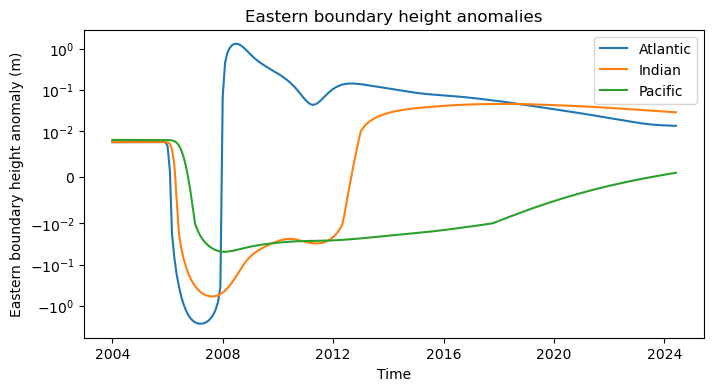

In [148]:
# Plot the eastern boundary height anomalies
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h_e.sel(region="north_atlantic").time, h_e.sel(region="north_atlantic").T, label="Atlantic")
ax.plot(h_e.sel(region="north_indian").time, h_e.sel(region="north_indian").T, label="Indian")
ax.plot(h_e.sel(region="north_pacific").time, h_e.sel(region="north_pacific").T, label="Pacific")
ax.set_xlabel("Time")
ax.set_ylabel("Eastern boundary height anomaly (m)")
ax.set_yscale("symlog", linthresh=1e-2)
ax.set_title("Eastern boundary height anomalies")
ax.legend()

Text(0.5, 1.0, 'Transport anomaly at 25 degrees N')

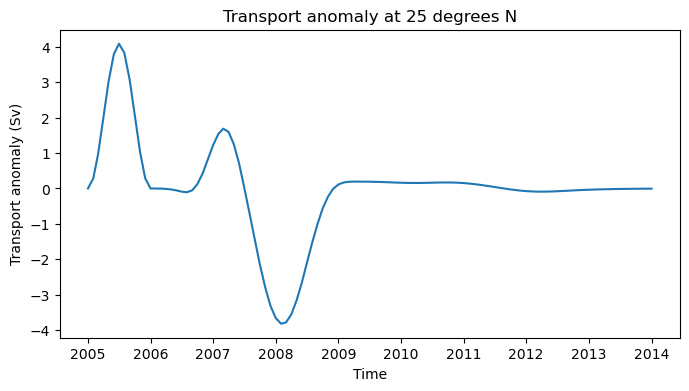

In [149]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_to_plot.time, T_to_plot.sel(latitude=25) / 1e6)
ax.set_xlabel("Time")
ax.set_ylabel("Transport anomaly (Sv)")
ax.set_title("Transport anomaly at 25 degrees N")

Because we are solving in Fourier space, the long-timescale adjustment wraps around to $t=0$. Thus we see that the long timescale adjustment leads to a small thickness anomaly in the Atlantic basin (ditto Indian ocean, with a small negative in the Pacific), and a small negative transport anomaly in the Atlantic. 

The transport anomaly induced by this burst is interesting, because there is the local-in-time Ekman adjustment but also a positive and negative geostrophic anomaly (at different latitudes) when the signals from the burst arrive at the western boundary region. The central latitude of the pulses do not line up straightforwardly with the induced geostrophic transports. 

The higher-latitude of the two lobes is more intense (but less diffuse?). This happens because the Rossby waves move slower at those latitudes, so the upwelling acts over a smaller wave train. There are two ways that the latitude affects the boundary anomaly due to a pulse of wind: both by changing the wind profile, and the speed of the Rossby waves. Slower waves accumulate more of an anomaly over a particular interval.

### High latitude North Atlantic
The high latitude North Atlantic is interesting because the crossing times start to flatten out (there is even an inversion). What happens if we place a burst here?

In [135]:
hlna_burst = zonal_wind_burst(
    tau_0=-1e-3,
    t_0=np.datetime64("2005-01-01"),
    t_1=np.datetime64("2006-01-01"),
    lat_0=35.0,
    lat_1=50.0,
    lon_0=-30.0,
    lon_1=-20.0,
)

In [136]:
# Solve the model
isobath_ds = xr.open_dataset(PROJECT_ROOT / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc").load()
model = GlobalRossbyModel(isobath_ds, g_prime=0.02)
solution = model.solve(hlna_burst)
h_b = solution.h_b
h = solution.h
T = solution.T
# Compute the travel times
g = solution.attrs["g_prime_m_s-2"]
H = solution.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(isobath_ds.latitude)) * np.radians(isobath_ds.x_eA - isobath_ds.x_wA)
c = rossby_speed(L.latitude, g, H)
tt = L / c

In [137]:
h_b_to_plot = h_b.sel(region="north_atlantic", time=slice("2005-01-01", "2014-01-01"), latitude=slice(0, 50))
h_b_to_plot = h_b_to_plot.compute()
T_to_plot = T.sel(region="north_atlantic", time=slice("2005-01-01", "2014-01-01"), latitude=slice(0, 50))
T_to_plot = T_to_plot.compute()
h_e = solution.h_e.compute()

Text(0.5, 1.0, 'Total northern Atlantic transport anomalies')

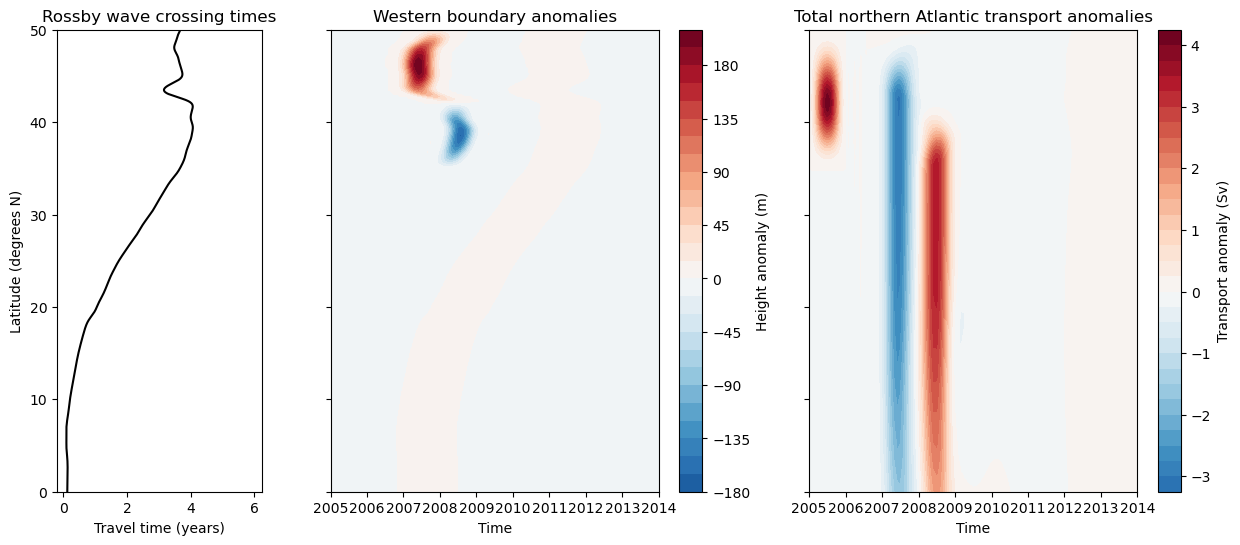

In [138]:
# Plot of travel times and h_b
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=True, width_ratios=[1, 2, 2])
# Plot travel times
tt_yr = tt / (24 * 60 * 60 * 365.25) # Convert seconds to years
tt_ax = axs[0]
tt_ax.plot(tt_yr, tt_yr.latitude, color="black")
tt_ax.set_xlabel("Travel time (years)")
tt_ax.set_ylabel("Latitude (degrees N)")
tt_ax.set_title("Rossby wave crossing times")
# Plot height anomalies over restricted region
h_b_ax = axs[1]
vmax = np.max(np.abs(h_b_to_plot))
ctf = h_b_ax.contourf(h_b_to_plot.time, h_b_to_plot.latitude, h_b_to_plot.T, cmap="RdBu_r", levels=31, norm=mpl.colors.CenteredNorm())
h_b_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=h_b_ax, label="Height anomaly (m)")
h_b_ax.set_title("Western boundary anomalies")
h_b_ax.set_ylim([h_b_to_plot.latitude.min(), h_b_to_plot.latitude.max()])
# Plot transport anomalies over restricted region
T_ax = axs[2]
vmax = np.max(np.abs(T_to_plot))
ctf = T_ax.contourf(T_to_plot.time, T_to_plot.latitude, T_to_plot.T / 1e6, cmap="RdBu_r", levels=31, norm=mpl.colors.CenteredNorm())
T_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=T_ax, label="Transport anomaly (Sv)")
T_ax.set_title("Total northern Atlantic transport anomalies")

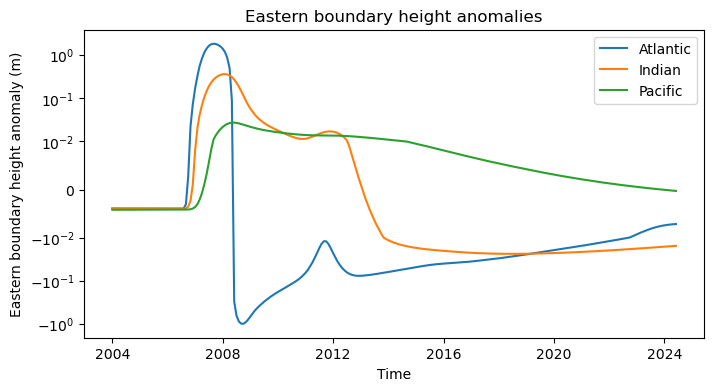

In [139]:
# Plot the eastern boundary height anomalies
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h_e.sel(region="north_atlantic").time, h_e.sel(region="north_atlantic").T, label="Atlantic")
ax.plot(h_e.sel(region="north_indian").time, h_e.sel(region="north_indian").T, label="Indian")
ax.plot(h_e.sel(region="north_pacific").time, h_e.sel(region="north_pacific").T, label="Pacific")
ax.set_xlabel("Time")
ax.set_ylabel("Eastern boundary height anomaly (m)")
ax.set_yscale("symlog", linthresh=1e-2)
ax.set_title("Eastern boundary height anomalies")
ax.legend()

We more-or-less just see an inverted effect here, with the low-frequency boundary response determined by the lower-latitude blob. Nevertheless, the peak $h_b$ value is set by the higher-latitude blob, maybe due to transport being stronger there due to $f$ increasing with latitude.

One thing that is novel here compared to the other case is that the remotely-generated transport anomalies are close in magnitude to the Ekman anomaly, despite being generated quite remotely. Below we plot the midlatitude (25 degree) transport anomaly as a function of time.

Text(0.5, 1.0, 'Transport anomaly at 25 degrees N')

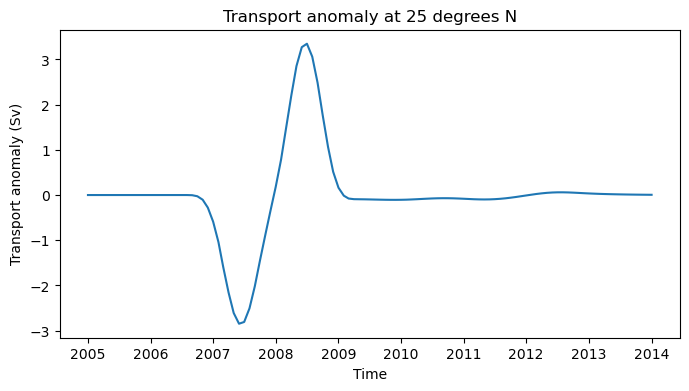

In [143]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_to_plot.time, T_to_plot.sel(latitude=25) / 1e6)
ax.set_xlabel("Time")
ax.set_ylabel("Transport anomaly (Sv)")
ax.set_title("Transport anomaly at 25 degrees N")

Is this due to the relatively flat (even inverting) nature of the high latitude crossing times, or is this just due to the fact that the wind is at high latitude where $f$ is high?